[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/assignments/assignment_combined_5_6.ipynb)

# Assignment 5 & 6: HRTEM Simulation and CTF Analysis

In this assignment, you will use the `abTEM` package to perform a multislice High-Resolution Transmission Electron Microscopy (HRTEM) simulation. You will build an atomic model, calculate its projected potential, simulate the electron wave propagation, and apply different Contrast Transfer Functions (CTFs) to understand how microscope parameters affect the final image.

## Learning Objectives
1. Understand the multislice algorithm for HRTEM simulation.
2. Explore the effects of the Contrast Transfer Function (CTF), including spherical aberration ($C_s$) and defocus ($\Delta f$).
3. Analyze the impact of aberration correction and noise on image quality.

---

## Part 1: Setup and Building the Atomic Model

First, we import the necessary libraries and build our atomic model. We will use a Silicon Nitride (Si$_3$N$_4$) crystal structure.

In [1]:
%matplotlib inline

import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt

print(f"abTEM version: {abtem.__version__}")

abTEM version: 1.0.8


### Define the Si$_3$N$_4$ Structure
We use the Atomic Simulation Environment (`ase`) to define the unit cell by providing the atomic positions and cell dimensions.

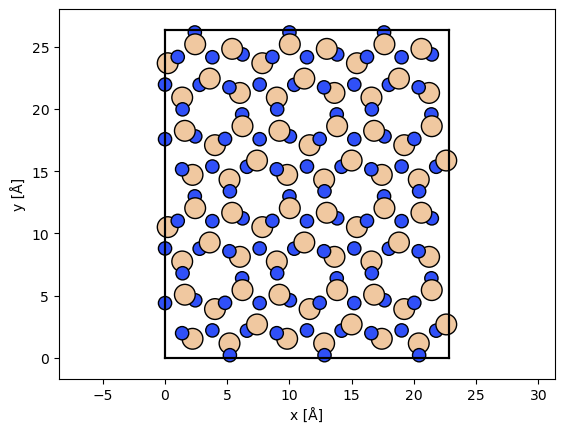

In [4]:
structure = ase.Atoms(
    'Si6N8',
    positions=[
      (4.015308131006949, 3.9110253242355126, 2.1788993100000003),
      (2.422878997737693, -1.15285715796029, 0.72629977),
      (5.3947013511357, -1.5218461833564767, 0.72629977),
      (2.2098430845971873, 1.521846183356477, 2.1788993100000003),
      (5.181665437995193, 1.1528571579602902, 2.1788993100000003),
      (3.5892363047259375, -3.9110253242355126, 0.72629977),
      (3.8022722178664434, 2.195242888517426, 2.1788993100000003),
      (3.802272217866444, -2.1952428885174267, 0.72629977),
      (6.2321062558996125, -1.9713791971906662, 2.1788993100000003),
      (4.8233175932090955, 4.411472738097657, 0.72629977),
      (5.211060880556961, 0.20287673026395847, 0.72629977),
      (2.3934835551759255, -0.20287673026395803, 2.1788993100000003),
      (1.3724381798332734, 1.9713791971906653, 0.72629977),
      (2.781226842523792, -4.411472738097657, 2.1788993100000003),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120]
)

# The multislice algorithm requires an orthogonal input cell.
structure_orthogonal = abtem.atoms.orthogonalize_cell(structure)

# Visualize the orthogonalized structure (tiled 3x2x6 for visualization)
abtem.show_atoms(structure_orthogonal * (3,2,6), plane='xy');

---

## Part 2: Calculate Projected Potentials

**TASK 1:** Calculate the projected potentials for the structure.
1. Create a `FrozenPhonons` object using the orthogonalized structure tiled by `(3, 2, 17)`. This gives a thickness of ~5 nm. Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N.
2. Create a `Potential` object using the frozen phonons, with a sampling of 0.1 Å, slice thickness of 2.0 Å, and the 'kirkland' parametrization.
3. Plot the mean-projected potential.

tasks:   0%|          | 0/17 [00:00<?, ?it/s]

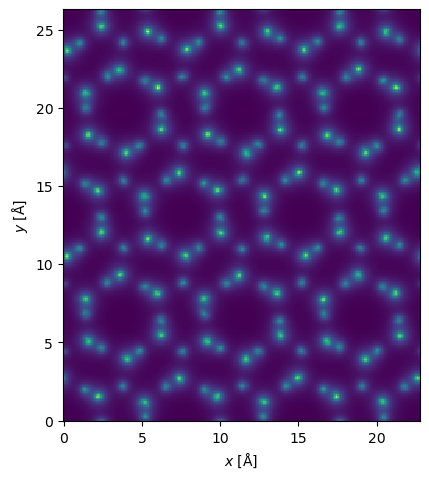

In [5]:
# TASK 1: Create FrozenPhonons
# Tile the structure by (3, 2, 17) to get ~5 nm thickness
# Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N
frozen_phonons = abtem.FrozenPhonons(
    structure_orthogonal * (3, 2, 17),
    num_configs=8,
    sigmas={'Si': 0.1, 'N': 0.1},  # thermal displacement in Å
)

# TASK 1: Create the Potential object
# Use sampling=0.1 Å, slice_thickness=2.0 Å, and the 'kirkland' parametrization
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,           # real-space sampling in Å/pixel
    slice_thickness=2.0,    # thickness of each projected slice in Å
    parametrization='kirkland',
)

# TASK 1: Plot the mean projected potential
# .project() collapses along z; .show() displays it
potential.project().show(cmap='viridis');


---

## Part 3: HRTEM Plane Wave Multislice Simulation

**TASK 2:** Perform the multislice simulation.
1. Initialize a `PlaneWave` with an energy of 300 keV.
2. Run the `multislice` algorithm using the potential you calculated.
3. Plot the mean intensity of the exit waves.

tasks:   0%|          | 0/25 [00:00<?, ?it/s]

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

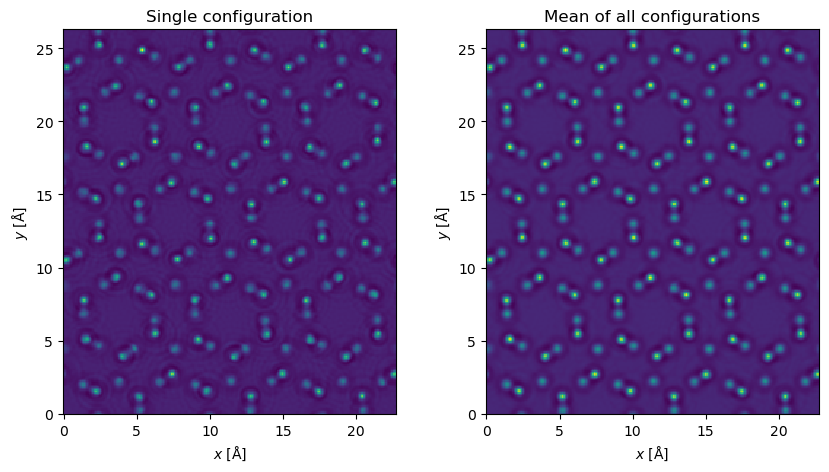

In [7]:
# TASK 2: Initialize the PlaneWave with 300 keV energy
wave = abtem.PlaneWave(energy=300e3)  # energy in eV

# TASK 2: Run the multislice simulation
# This propagates the wave through each slice of the potential
exit_waves = wave.multislice(potential)

# TASK 2: Plot the mean intensity of the exit waves
# .intensity() computes |ψ|², .mean(0) averages over frozen phonon configs
fig, ax = plt.subplots(1, 2, figsize=(10,5))
exit_waves.show(ax=ax[0], cmap='viridis')
ax[0].set_title('Single configuration')
exit_waves.intensity().mean(0).show(ax=ax[1], cmap='viridis')
ax[1].set_title('Mean of all configurations');

---

## Part 4: Contrast Transfer Function (CTF)

The exit wave represents the electron wave immediately after leaving the sample. To simulate the final image, we must apply the Contrast Transfer Function (CTF) of the microscope.

**TASK 3:** Define and apply different CTFs.
1. Define an **uncorrected CTF** with $C_{10} = -600$ Å (defocus) and $C_{30} = 1.3 \times 10^7$ Å ($C_s = 1.3$ mm).
2. Define an **aberration-corrected CTF** with $C_{10} = 30$ Å and $C_{30} = -8 \times 10^4$ Å.
3. Plot both CTFs to compare them.
4. Apply both CTFs to your `exit_waves` and plot the resulting mean image intensities.

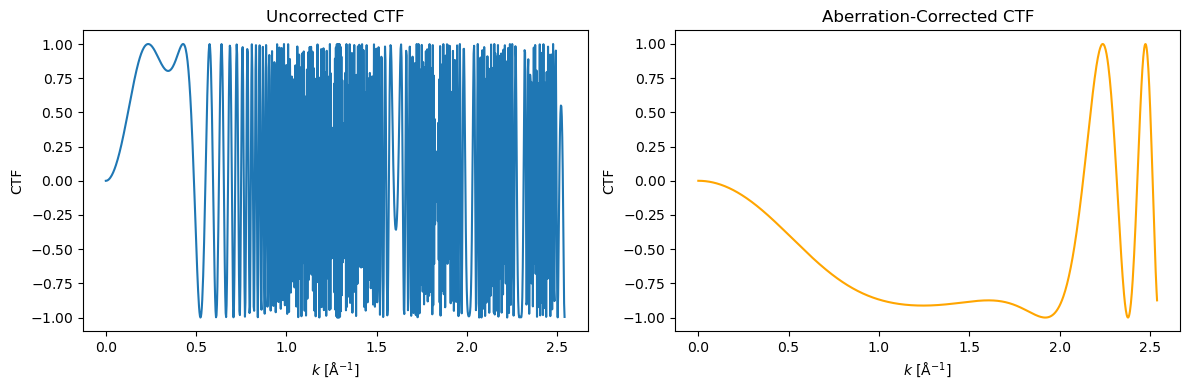

In [32]:
# TASK 3a: Define the UNCORRECTED CTF
parameters_uncorrected = {
    "C10": -600,   # defocus in Å
    "C30": 1.3e7,  # Cs = 1.3 mm = 1.3e7 Å
    "C50": 5e7,
}

ctf_uncorrected = abtem.CTF(energy=300e3, **parameters_uncorrected)

# TASK 3b: Define the ABERRATION-CORRECTED CTF
parameters_corrected = {
    "C10": 30,
    "C30": -8e4,
    "C50": 5e7,
}

ctf_corrected = abtem.CTF(energy=300e3, **parameters_corrected)

# TASK 3c: Plot radial CTF profiles
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左圖：Uncorrected
ctf_uncorrected.profiles(max_angle=50).show(ax=axes[0], units="mrad")
axes[0].set_title("Uncorrected CTF")
axes[0].set_ylabel("CTF")


# 右圖：Aberration-Corrected
ctf_corrected.profiles(max_angle=50).show(ax=axes[1], units="mrad")
axes[1].lines[-1].set_color("orange")   # 把右圖線改成橘色
axes[1].set_title("Aberration-Corrected CTF")
axes[1].set_ylabel("CTF")


plt.tight_layout()
plt.show()

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

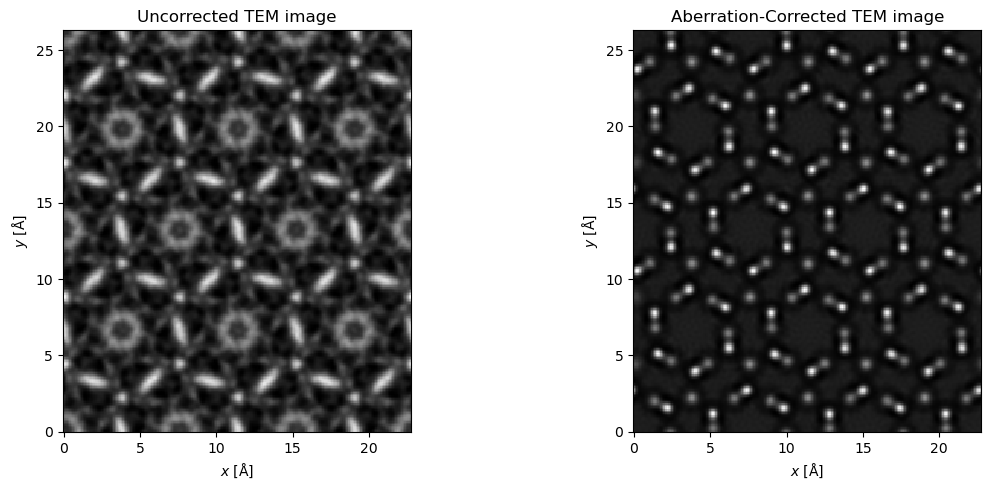

In [33]:
# TASK 3d: Apply each CTF to the exit waves
# .apply_ctf() convolves the exit wave with the CTF in Fourier space
image_uncorrected = exit_waves.apply_ctf(ctf_uncorrected)
image_corrected   = exit_waves.apply_ctf(ctf_corrected)

# TASK 3d: Plot the resulting mean image intensities side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

image_uncorrected.intensity().mean(0).show(cmap='gray', ax=axes[0])
axes[0].set_title('Uncorrected TEM image')

image_corrected.intensity().mean(0).show(cmap='gray', ax=axes[1])
axes[1].set_title('Aberration-Corrected TEM image')

plt.tight_layout()
plt.show()


---

## Part 5: Noise and Dose

Real TEM images are affected by Poisson noise due to the finite electron dose.

**TASK 4:** Apply Poisson noise to your images.
1. Use `abtem.noise.poisson_noise` to apply a dose of $100$ $e^-$/Å$^2$ to your aberration-corrected image.
2. Plot the noisy image alongside the noiseless one for comparison.

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/33 [00:00<?, ?it/s]

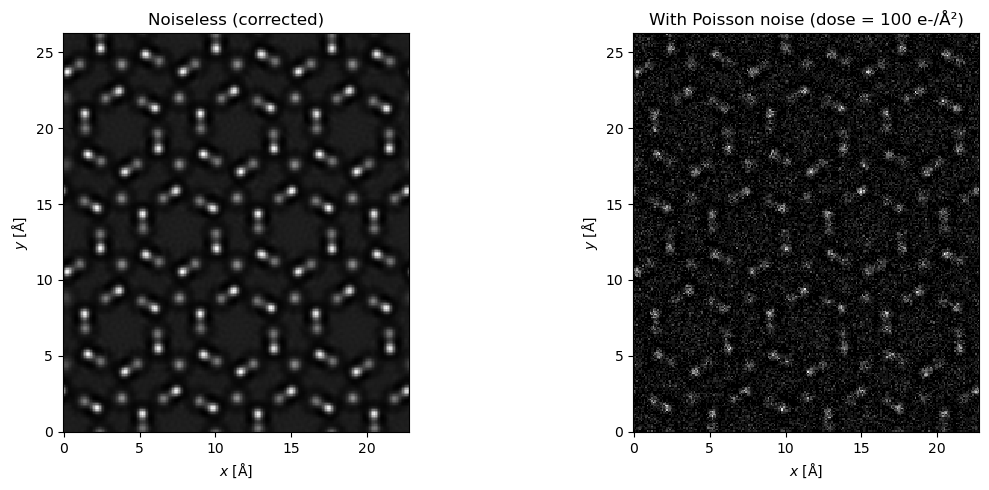

In [35]:
# TASK 4: Apply Poisson noise to the aberration-corrected image
# dose is in electrons per Å^2; lower dose = more noise
dose = 100  # e-/Å^2

# First get the noiseless mean intensity image, then add noise
noiseless_image = image_corrected.intensity().mean(0)
noisy_image = noiseless_image.poisson_noise(dose_per_area=dose)

# TASK 4: Plot the noiseless vs noisy images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

noiseless_image.show(cmap="gray", ax=axes[0])
axes[0].set_title("Noiseless (corrected)")

noisy_image.show(cmap="gray", ax=axes[1])
axes[1].set_title(f"With Poisson noise (dose = {dose} e-/Å²)")

plt.tight_layout()
plt.show()

---

# Task 6: Self-Reflection

Based on your simulations above, answer the following questions:

**1. Contrast Transfer Function (CTF):**
- How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer?
- Why do we see sharper atomic columns in the aberration-corrected image?

**2. Defocus and Contrast:**
- Why don't we typically image at exactly zero defocus ($\Delta f = 0$) in a conventional (uncorrected) TEM?
- What is the significance of the Scherzer defocus?

**3. Simulation vs. Reality:**
- How does adding Poisson noise change the interpretability of the image?
- What other experimental factors (not simulated here) might degrade the quality of a real HRTEM image?

**4. Multislice Algorithm:**
- Why is the multislice method necessary for a 5 nm thick sample, rather than just using a single projected potential (kinematic approximation)?

### Your Answers:

**1. Contrast Transfer Function (CTF):**

(1) Aberration-corrected CTF can transmit high spatial frequency information more stably, while uncorrected CTF will start to oscillate violently earlier, and much high-frequency information will be weakened, reversed, or even not transmitted clearly. In other words, a corrected microscope is more capable of accurately transmitting fine structures to the image.

(2) Because atomic columns are such fine structures, requiring high spatial frequency information to be clearly represented, aberration-corrected TEM is better able to preserve these high-frequency signals. Therefore, the boundaries of atomic columns are clearer, more concentrated, and less blurred.

**2. Defocus and Contrast:**

(1) Because in a traditional uncorrected TEM, if it happens to be zero focal length, the image contrast is usually not good enough, and many structural details are not easily converted into brightness variations. Therefore, in experiments, a little defocus is deliberately added to make the contrast of a certain important spatial frequency stronger.

(2) Scherzer defocus is an optimal defocus condition commonly used in traditional TEM. Its purpose is to allow the microscope to provide good contrast transfer over a large spatial frequency range, even when spherical aberration exists. It doesn't aim for perfection in everything but rather to find the focal length that best suits the overall requirements for viewing details within the limitations of the instrument.

**3. Simulation vs. Reality:**

(1)Adding Poisson noise makes the image grainier, with more chaotic brightness and contrast, and makes small details harder to discern. In particular, very weak signals may be masked by the noise.

(2) 1. Sample drift 2. Mechanical vibration 3. Electron beam instability 4. Astigmatism 5. Uneven sample thickness or surface contamination 6. Mis-tilt 7. Inelastic scattering and absorption effects 8. Beam damage

**4. Multislice Algorithm:**

For a 5 nm thick sample, electron waves undergo layer-by-layer propagation and multiple scattering within the sample, therefore a single projected potential energy cannot be used as an approximation. Multislice can more accurately describe the actual behavior of electron waves in thick samples.